In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# Load your cleaned CSV file
df = pd.read_csv("cleaned_data.csv")

# Quick check
print(df.head())
print("\nColumns:")
print(df.columns)
print("\nShape:", df.shape)

  transmission   mileage    tax   mpg fuel type  engine size  price_cad  \
0    Automatic   44900.0  160.0  46.3    Petrol          1.6    18390.8   
1    Automatic   88200.0  125.0  58.9    Diesel          2.1    12870.8   
2    Automatic  115000.0  145.0  54.3    Diesel          2.1    13790.8   
3    Automatic   69250.0  150.0  53.3    Diesel          2.1    16550.8   
4    Automatic   49850.0   30.0  62.8    Diesel          2.1    27590.8   

   car_age  
0     13.0  
1     14.0  
2     14.0  
3     15.0  
4     11.0  

Columns:
Index(['transmission', 'mileage', 'tax', 'mpg', 'fuel type', 'engine size',
       'price_cad', 'car_age'],
      dtype='object')

Shape: (3898, 8)


In [3]:
# X = input features
# y = target we want to predict

X = df.drop("price_cad", axis=1)
y = df["price_cad"]

print("Feature columns:")
print(X.columns.tolist())
print("\nTarget column:")
print(y.name)

Feature columns:
['transmission', 'mileage', 'tax', 'mpg', 'fuel type', 'engine size', 'car_age']

Target column:
price_cad


In [4]:
# Separate numeric and categorical columns
numeric_features = ["mileage", "tax", "mpg", "engine size", "car_age"]
categorical_features = ["transmission", "fuel type"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['mileage', 'tax', 'mpg', 'engine size', 'car_age']
Categorical features: ['transmission', 'fuel type']


In [5]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3118, 7)
X_test shape: (780, 7)


In [6]:
# Preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [7]:
# Create KNN regression pipeline
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

In [8]:
# Fit the model on training data
knn_model.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [9]:
# Predict prices for the test set
y_pred = knn_model.predict(X_test)

# Show a few predictions
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(results.head(10))

   Actual Price  Predicted Price
0      79101.60        68858.688
1      57958.16        62921.376
2      36606.80        42299.392
3      37350.16        36563.376
4      36790.80        42790.304
5      41887.60        36631.456
6      45352.32        46145.360
7      43056.00        33055.232
8      40112.00        38104.192
9      47376.32        42944.128


In [10]:
# Performance metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("KNN Regression Performance Metrics")
print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

KNN Regression Performance Metrics
R²   : 0.9261
MSE  : 22490168.32
RMSE : 4742.38


In [11]:
k_values = range(1, 21)

r2_scores = []
mse_scores = []
rmse_scores = []

for k in k_values:
    knn_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])
    
    knn_pipeline.fit(X_train, y_train)
    y_pred_k = knn_pipeline.predict(X_test)
    
    r2_k = r2_score(y_test, y_pred_k)
    mse_k = mean_squared_error(y_test, y_pred_k)
    rmse_k = np.sqrt(mse_k)
    
    r2_scores.append(r2_k)
    mse_scores.append(mse_k)
    rmse_scores.append(rmse_k)

# Put results into a table
k_results = pd.DataFrame({
    "k": list(k_values),
    "R2": r2_scores,
    "MSE": mse_scores,
    "RMSE": rmse_scores
})

print(k_results)

     k        R2           MSE         RMSE
0    1  0.887489  3.422357e+07  5850.091308
1    2  0.915128  2.581658e+07  5081.002023
2    3  0.926942  2.222280e+07  4714.107002
3    4  0.925077  2.279013e+07  4773.901401
4    5  0.926063  2.249017e+07  4742.380027
5    6  0.923074  2.339928e+07  4837.280007
6    7  0.922148  2.368118e+07  4866.330845
7    8  0.919865  2.437560e+07  4937.164739
8    9  0.919206  2.457586e+07  4957.404191
9   10  0.917901  2.497294e+07  4997.293351
10  11  0.916474  2.540711e+07  5040.546828
11  12  0.914788  2.591975e+07  5091.144122
12  13  0.912104  2.673627e+07  5170.712437
13  14  0.911243  2.699826e+07  5195.984992
14  15  0.911302  2.698036e+07  5194.262297
15  16  0.909563  2.750935e+07  5244.935374
16  17  0.907585  2.811095e+07  5301.976339
17  18  0.906085  2.856709e+07  5344.819381
18  19  0.903132  2.946535e+07  5428.199888
19  20  0.903623  2.931606e+07  5414.431067


In [12]:
# Best k based on highest R²
best_row = k_results.loc[k_results["R2"].idxmax()]

print("Best K based on highest R²:")
print(best_row)

Best K based on highest R²:
k       3.000000e+00
R2      9.269422e-01
MSE     2.222280e+07
RMSE    4.714107e+03
Name: 2, dtype: float64


In [13]:
best_k = int(best_row["k"])

final_knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=best_k))
])

final_knn_model.fit(X_train, y_train)
final_y_pred = final_knn_model.predict(X_test)

final_r2 = r2_score(y_test, final_y_pred)
final_mse = mean_squared_error(y_test, final_y_pred)
final_rmse = np.sqrt(final_mse)

print(f"Final KNN Model (k={best_k})")
print(f"R²   : {final_r2:.4f}")
print(f"MSE  : {final_mse:.2f}")
print(f"RMSE : {final_rmse:.2f}")

Final KNN Model (k=3)
R²   : 0.9269
MSE  : 22222804.83
RMSE : 4714.11


In [14]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_y_pred,
    "Difference": y_test.values - final_y_pred
})

print(comparison_df.head(15))

    Actual Price  Predicted Price    Difference
0       79101.60     72064.213333   7037.386667
1       57958.16     61298.373333  -3340.213333
2       36606.80     41183.493333  -4576.693333
3       37350.16     36541.173333    808.986667
4       36790.80     46361.866667  -9571.066667
5       41887.60     39021.493333   2866.106667
6       45352.32     47561.546667  -2209.226667
7       43056.00     33024.933333  10031.066667
8       40112.00     38044.453333   2067.546667
9       47376.32     40294.160000   7082.160000
10      26770.16     28911.920000  -2141.760000
11      81254.40     57671.120000  23583.280000
12      42872.00     33083.813333   9788.186667
13      27222.80     24340.133333   2882.666667
14      48758.16     46354.506667   2403.653333


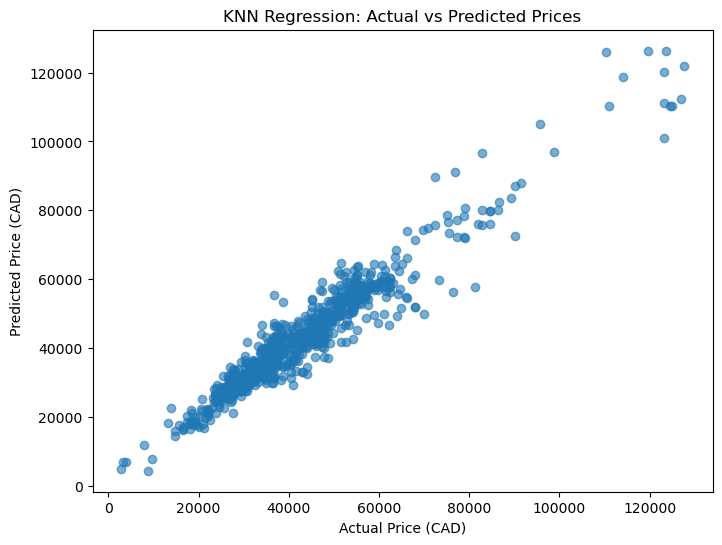

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, final_y_pred, alpha=0.6)
plt.xlabel("Actual Price (CAD)")
plt.ylabel("Predicted Price (CAD)")
plt.title("KNN Regression: Actual vs Predicted Prices")
plt.show()